In [26]:
import numpy as np

Male, Female = (0, 1)
Young, Adult = (0, 1)

# 短跑, 跳远, 跳高, 引体向上, 心率
params = {
    (Male, Young): [(14.5, 1.2), (4.8, 0.5), (1.4, 0.2), (12, 3), (70, 5)],
    (Male, Adult): [(13.2, 0.8), (5.2, 0.4), (1.5, 0.15), (15, 2.5), (68, 4)],
    (Female, Young): [(16.8, 1.0), (3.9, 0.4), (1.2, 0.15), (8, 2), (75, 6)],
    (Female, Adult): [(15.5, 0.9), (4.1, 0.3), (1.3, 0.1), (10, 1.8), (72, 5)]
}

segment_data = []
for group, param in params.items():
    gender, age = group
    
    group_data = []
    for (mu, sigma) in param:
        group_data.append(np.random.normal(mu, sigma, 500))
        
    group_data.append(np.full(500, gender))
    group_data.append(np.ones(500) * age)
    
    # print(np.concatenate(group_data, axis=1).shape)
    segment_data.append(np.column_stack(group_data))
    
data = np.row_stack(segment_data)
print(np.concatenate(segment_data, axis=0)[:5])


[[13.75848283  5.46503965  1.58409997 10.82250978 72.19630103  0.
   0.        ]
 [13.56594934  6.04622573  1.39246385  9.70920998 69.60723385  0.
   0.        ]
 [13.63851675  3.81974561  1.34666376  6.96057617 68.90745975  0.
   0.        ]
 [15.04956908  4.67044925  1.31547244 10.02431557 76.86191527  0.
   0.        ]
 [14.42748687  4.74397759  1.3868239  13.46596461 70.4118915   0.
   0.        ]]


In [52]:
indexes = np.arange(1, 2001).reshape(-1, 1)
data_indexed = np.column_stack((indexes, data))

data_indexed[data_indexed[:, 0] % 2 == 1]

for group in params:
    gender, age = group
    
    t1 = data_indexed[:,-1] == age
    t2 = data_indexed[:,-2] == gender
    
    group_data = data_indexed[t1 & t2]
    # print(np.argsort(group_data[:, 4]))
    sorted_group_data = group_data[np.argsort(-group_data[:, 4])]
    # print('\n', sorted_group_data[::-1][:10])
    print('\n', sorted_group_data[:10])


 [[181.          14.6055876    4.23102195   1.47882958  23.76500517
   62.55146202   0.           0.        ]
 [297.          16.96188564   4.838582     1.40543462  19.47576492
   66.84802409   0.           0.        ]
 [143.          14.40572424   4.61816521   1.60503225  19.02771447
   68.47174383   0.           0.        ]
 [185.          18.80495057   5.14333375   1.37462999  18.9526683
   68.03169069   0.           0.        ]
 [371.          14.46669554   4.31417292   1.58509654  18.82671426
   71.01778109   0.           0.        ]
 [404.          12.90163536   4.43358312   1.65652773  18.72145389
   68.93191722   0.           0.        ]
 [267.          14.21673272   5.0264656    1.31162563  18.5357215
   72.41398963   0.           0.        ]
 [345.          12.69725053   4.2384691    1.25254658  18.49080121
   68.28377895   0.           0.        ]
 [338.          12.02902915   4.98279143   1.06122749  18.46723221
   72.44931285   0.           0.        ]
 [133.          12.

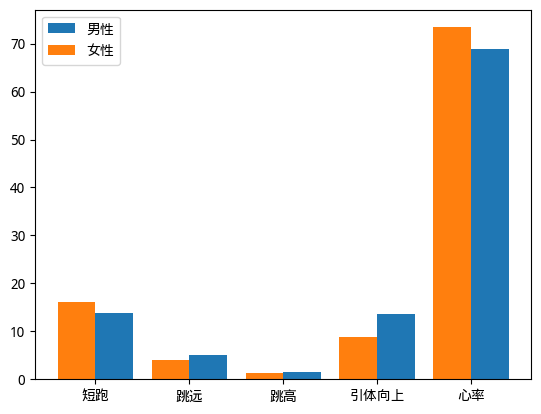

In [75]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'WenQuanYi Micro Hei'

mask = data_indexed[:,-2] == 0
data_man = data_indexed[mask]
data_woman = data_indexed[~mask]

man_means = np.mean(data_man[:, 1:-2], axis=0)
woman_means = np.mean(data_woman[:, 1:-2], axis=0)

xlabels = ['短跑', '跳远', '跳高', '引体向上', '心率']
x = np.arange(len(xlabels))

fig, ax = plt.subplots()

ax.bar(x+0.2, man_means, 0.4, label='男性')
ax.bar(x-0.2, woman_means, 0.4, label='女性')

ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend()

plt.show()

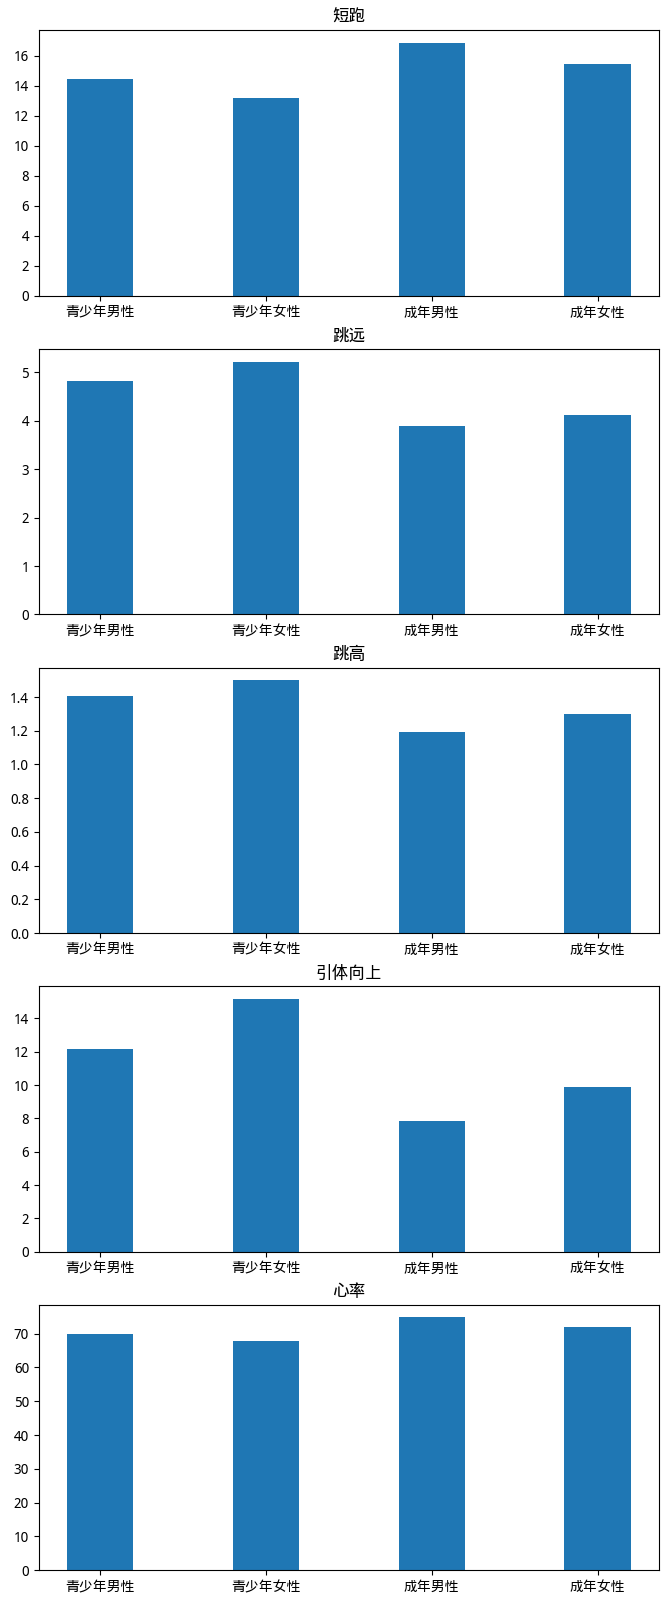

In [83]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'WenQuanYi Micro Hei'

means = []
for group in params:
    gender, age = group
    mask = (data_indexed[:,-1] == age) & (data_indexed[:,-2] == gender)
    group_data = data_indexed[mask]
    means.append(np.mean(group_data[:, 1:-2], axis = 0))

stacked_means = np.stack(means)
x = np.arange(4)
xlabels = ['青少年男性', '青少年女性', '成年男性', '成年女性']

# mask = data_indexed[:,-2] == 0
# data_man = data_indexed[mask]
# data_woman = data_indexed[~mask]

# man_means = np.mean(data_man[:, 1:-2], axis=0)
# woman_means = np.mean(data_woman[:, 1:-2], axis=0)

titles = ['短跑', '跳远', '跳高', '引体向上', '心率']

fig, axes = plt.subplots(5, figsize=(8, 20))

for i in range(5):
    ax = axes[i]
    ax.bar(x, stacked_means[:,i], 0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_title(titles[i])

plt.show()